# Layer 1; 32; 3x3; AvgPool

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


## Import Libraries

In [1]:
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
tf.test.is_built_with_cuda()

2026-05-12 15:26:12.823473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778599573.241219      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778599573.355945      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778599574.476856      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778599574.476900      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778599574.476903      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


True

## Config

In [2]:
TRAIN_DIR  = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
VAL_DIR    = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'
TEST_DIR   = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred'
MODEL_DIR = '/kaggle/working/models/cnn'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 64
EPOCHS      = 10
NUM_CLASSES = 6
LR          = 1e-4
VAL_SPLIT   = 0.2

## Import Dataset

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

normalization = keras.layers.Rescaling(1.0 / 255.0)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

train_ds = (
    train_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

train_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
val_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
test_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=1, label_mode="int", shuffle=False
))

print("Kelas      :", {name: i for i, name in enumerate(class_names)})
print(f"Train      : {train_count} gambar")
print(f"Validation : {val_count} gambar")
print(f"Test       : {test_count} gambar")

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1778599622.918438      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778599622.924446      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Kelas      : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Train      : 11228 gambar
Validation : 2806 gambar
Test       : 3000 gambar


## CNN Model Baseline Architecture

In [47]:
MODEL_NAME = 'Layer-1-64-3x3-Avgpool'
model = keras.Sequential([
    keras.layers.Input(shape=IMG_SIZE + (3,), name='input'),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2s_1'),
    keras.layers.AveragePooling2D((2, 2), name='avgpool_1'),
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(128, activation='relu', name='dense_1'),
    keras.layers.Dense(6, activation='softmax', name='output'),
], name=MODEL_NAME)
model.summary()

Model: "Layer-1-64-3x3-Avgpool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2s_1 (Conv2D)               │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool_1 (AveragePooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 350464)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    44,859,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,862,086 (171.14 MB)

 Trainable params: 44,862,086 (171.14 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation and Training

In [48]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callback = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'/kaggle/working/models/cnn/{MODEL_NAME}.h5',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback,
    verbose=1
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4134 - loss: 1.8632
Epoch 1: val_loss improved from inf to 0.92994, saving model to /kaggle/working/models/cnn/Layer-1-64-3x3-Avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.4141 - loss: 1.8602 - val_accuracy: 0.6447 - val_loss: 0.9299
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6647 - loss: 0.9129
Epoch 2: val_loss improved from 0.92994 to 0.51144, saving model to /kaggle/working/models/cnn/Layer-1-64-3x3-Avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6648 - loss: 0.9128 - val_accuracy: 0.8550 - val_loss: 0.5114
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7254 - loss: 0.7766
Epoch 3: val_loss improved from 0.51144 to 0.43794, saving model to /kaggle/working/models/cnn/Layer-1-64-3x3-Avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7254 - loss: 0.7766 - val_accuracy: 0.8671 - val_loss: 0.4379
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7482 - loss: 0.7137
Epoch 4: val_loss did not improve from 0.43794
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.7482 - loss: 0.7136 - val_accuracy: 0.7969 - val_loss: 0.6038
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7882 - loss: 0.6350
Epoch 5: val_loss did not improve from 0.43794
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.7882 - loss: 0.6349 - val_accuracy: 0.8389 - val_loss: 0.5147
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8092 - loss: 0.5688
Epoch 6: val_loss did not improve from 0.43794
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8093 - loss: 0.5688 - val_accuracy: 0.8685 - val_loss: 0.4535
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8386 - loss: 0.5119
Epoch 7: val_loss improved from 0.43794

176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8385 - loss: 0.5119 - val_accuracy: 0.8902 - val_loss: 0.4019
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8531 - loss: 0.4725
Epoch 8: val_loss improved from 0.40192 to 0.25083, saving model to /kaggle/working/models/cnn/Layer-1-64-3x3-Avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8531 - loss: 0.4725 - val_accuracy: 0.9391 - val_loss: 0.2508
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8714 - loss: 0.4314
Epoch 9: val_loss did not improve from 0.25083
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8713 - loss: 0.4315 - val_accuracy: 0.8019 - val_loss: 0.5759
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8723 - loss: 0.4080
Epoch 10: val_loss improved from 0.25083 to 0.22382, saving model to /kaggle/working/models/cnn/Layer-1-64-3x3-Avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8723 - loss: 0.4079 - val_accuracy: 0.9408 - val_loss: 0.2238
Restoring model weights from the end of the best epoch: 10.


## Evaluation

In [49]:
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
Macro F1 Score: 0.7346


## Plot

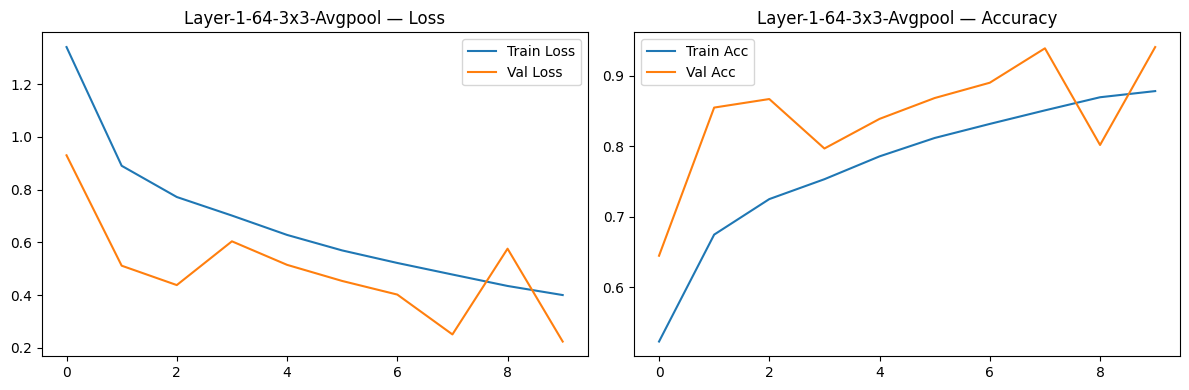

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train Loss')
ax1.plot(history.history['val_loss'],     label='Val Loss')
ax1.set_title(f'{MODEL_NAME} — Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title(f'{MODEL_NAME} — Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, f'{MODEL_NAME}_curve.png'), dpi=100)
plt.show()